## Mid term Data visualizations by Dancing Dolphins

In [ ]:
import pandas as pd

url = "https://storage.googleapis.com/covid19-open-data/v3/epidemiology.csv"
df = pd.read_csv(url)

In [15]:
df["location_key"] = df["location_key"].fillna("")

df_states = df[df["location_key"].str.match(r"US_[A-Z]{2}$")].copy()

In [16]:
df_states["location_key"].unique()[:10]

array(['US_AK', 'US_AL', 'US_AR', 'US_AS', 'US_AZ', 'US_CA', 'US_CO',
       'US_CT', 'US_DC', 'US_DE'], dtype=object)

In [17]:
df_us = df_states.groupby("date")[["new_confirmed", "cumulative_confirmed"]].sum().reset_index()
df_us["date"] = pd.to_datetime(df_us["date"])
df_us = df_us.sort_values("date")

In [18]:
df_us["new_confirmed_ma7"] = df_us["new_confirmed"].rolling(7).mean()

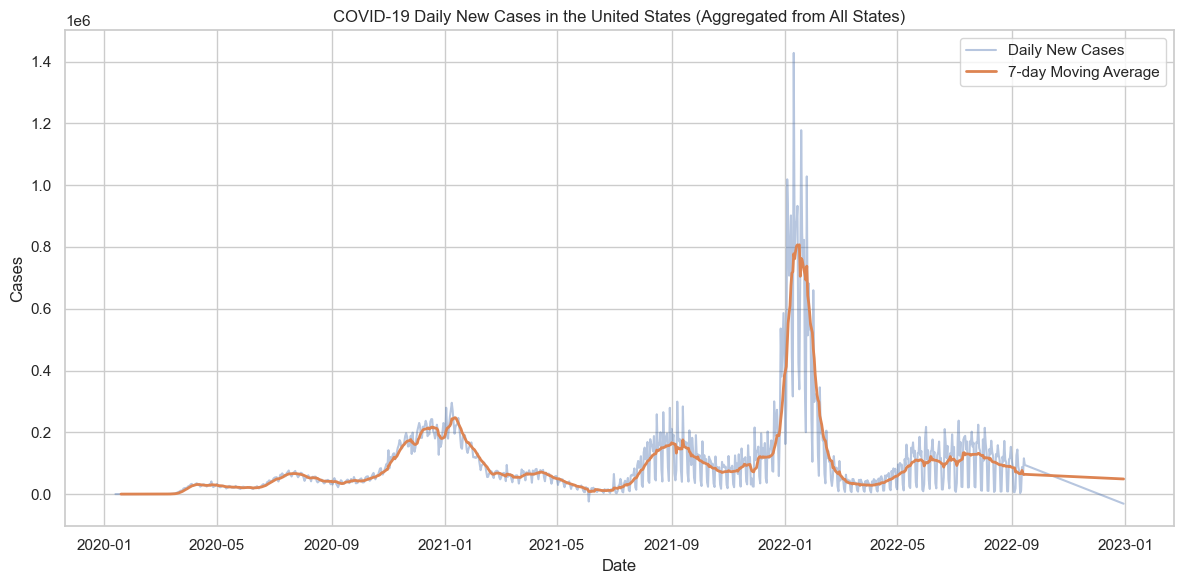

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")
plt.figure(figsize=(12,6))

plt.plot(df_us["date"], df_us["new_confirmed"], 
         label="Daily New Cases", alpha=0.4)

plt.plot(df_us["date"], df_us["new_confirmed_ma7"], 
         label="7-day Moving Average", linewidth=2)

plt.title("COVID-19 Daily New Cases in the United States (Aggregated from All States)")
plt.xlabel("Date")
plt.ylabel("Cases")
plt.legend()
plt.tight_layout()
plt.show()

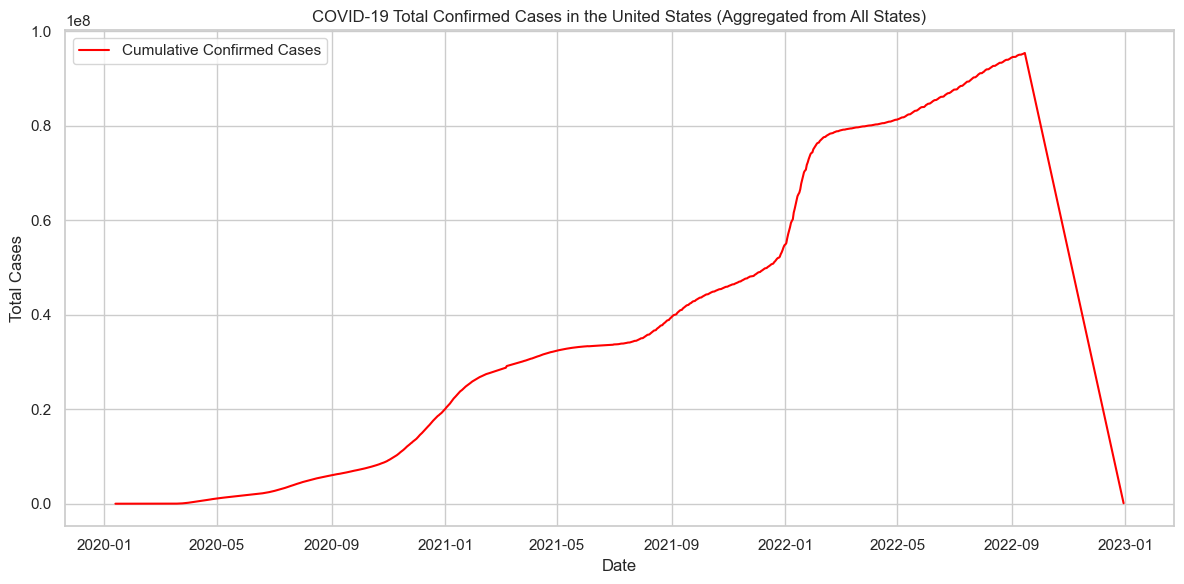

In [20]:
plt.figure(figsize=(12,6))

plt.plot(df_us["date"], df_us["cumulative_confirmed"], 
         label="Cumulative Confirmed Cases", color="red")

plt.title("COVID-19 Total Confirmed Cases in the United States (Aggregated from All States)")
plt.xlabel("Date")
plt.ylabel("Total Cases")
plt.legend()
plt.tight_layout()
plt.show()

In [1]:
## Visualization 2: Netflix data analysis 

  https://naturalearth.s3.amazonaws.com/110m_cultural/ne_110m_admin_0_countries.zip
✓ Shapefile loaded successfully.

Saved → netflix_world_map.png


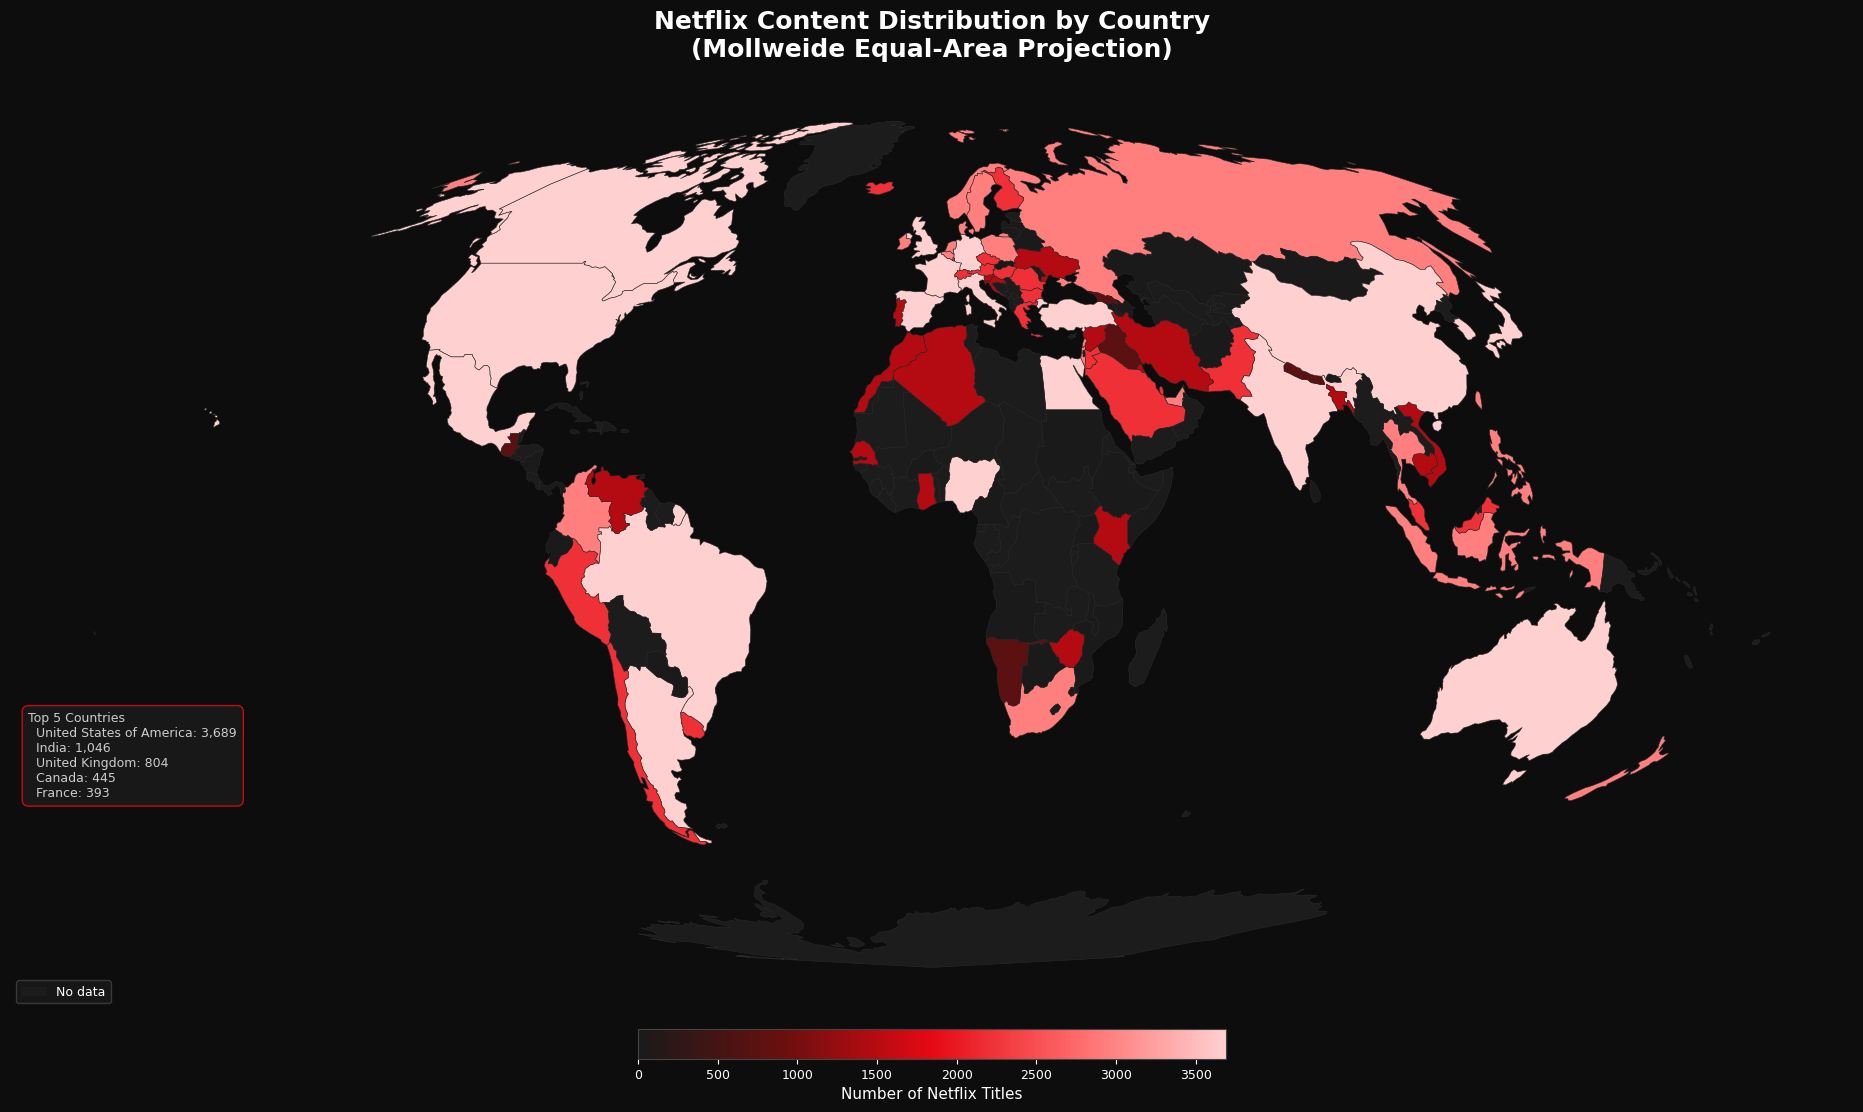

In [3]:
"""
Netflix Titles – World Map (Equal-Area / Mollweide Projection)
==============================================================
Requirements:
    pip install pandas geopandas matplotlib mapclassify requests geodatasets

Dataset:
    netflix_titles.csv  (place it in the same directory, or update CSV_PATH)

Shapefile sources (tried automatically in order):
  1. naturalearth.s3.amazonaws.com  — official AWS-hosted zip  ← PRIMARY
  2. naturalearthdata.com            — official site direct link
  3. geodatasets package             — pip install geodatasets  (offline fallback)
"""

import io
import zipfile
import requests
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import LinearSegmentedColormap
import warnings
warnings.filterwarnings("ignore")

# ── 1. Config ────────────────────────────────────────────────────────────────
CSV_PATH   = "netflix_titles.csv"   # ← update path if needed
PROJECTION = "ESRI:54009"           # Mollweide equal-area
# Alternatives:
#   "EPSG:6933"   → WGS 84 / NSIDC EASE-Grid 2.0 Global
#   "ESRI:54034"  → World Cylindrical Equal Area
#   "ESRI:102003" → Albers Equal-Area Conic (North America)

# ── 2. Load world shapefile (with automatic fallbacks) ────────────────────────
URLS = [
    # ✅ PRIMARY — Natural Earth official AWS S3 bucket
    "https://naturalearth.s3.amazonaws.com/110m_cultural/ne_110m_admin_0_countries.zip",
    # ✅ BACKUP — naturalearthdata.com direct link
    "https://www.naturalearthdata.com/http//www.naturalearthdata.com/download/110m/cultural/ne_110m_admin_0_countries.zip",
]

world = None

for url in URLS:
    try:
        print(f"Downloading shapefile from:\n  {url}")
        r = requests.get(url, timeout=30)
        r.raise_for_status()
        with zipfile.ZipFile(io.BytesIO(r.content)) as z:
            z.extractall("ne_110m_countries")
        world = gpd.read_file("ne_110m_countries/ne_110m_admin_0_countries.shp")
        print("✓ Shapefile loaded successfully.\n")
        break
    except Exception as e:
        print(f"  ✗ Failed: {e}")

if world is None:
    # Last resort: geodatasets package (pip install geodatasets)
    try:
        import geodatasets
        print("Falling back to geodatasets package...")
        world = gpd.read_file(geodatasets.get_path("naturalearth land"))
        print("✓ Shapefile loaded via geodatasets.\n")
    except Exception as e:
        raise RuntimeError(
            "\nCould not load world shapefile from any source.\n"
            "Try:  pip install geodatasets\n"
            f"Error: {e}"
        )

# Keep only name + geometry
name_col = "ADMIN" if "ADMIN" in world.columns else "name"
world = world[[name_col, "geometry"]].rename(columns={name_col: "name"})

# ── 3. Load & clean Netflix data ──────────────────────────────────────────────
df = pd.read_csv(CSV_PATH)

# Explode multi-country rows  e.g. "United States, India" → two separate rows
df["country"] = df["country"].fillna("Unknown")
df = df.assign(country=df["country"].str.split(", ")).explode("country")
df["country"] = df["country"].str.strip()
df = df[df["country"] != "Unknown"]

# Count titles per country
country_counts = df.groupby("country").size().reset_index(name="titles")

# ── 4. Name harmonisation ─────────────────────────────────────────────────────
name_fixes = {
    "United States"  : "United States of America",
    "Czech Republic" : "Czechia",
    "Soviet Union"   : "Russia",
    "West Germany"   : "Germany",
    "East Germany"   : "Germany",
    "Taiwan"         : "Taiwan",
    "South Korea"    : "South Korea",
    "North Korea"    : "North Korea",
}
country_counts["country"] = country_counts["country"].replace(name_fixes)

# Re-aggregate after fixes (some countries now share a name)
country_counts = country_counts.groupby("country", as_index=False)["titles"].sum()

# ── 5. Merge ──────────────────────────────────────────────────────────────────
world = world.merge(country_counts, left_on="name", right_on="country", how="left")
world["titles"] = world["titles"].fillna(0).astype(int)

# ── 6. Reproject to equal-area ────────────────────────────────────────────────
world_ea = world.to_crs(PROJECTION)

# ── 7. Custom Netflix colormap ────────────────────────────────────────────────
netflix_cmap = LinearSegmentedColormap.from_list(
    "netflix",
    ["#1a1a1a", "#6b0f0f", "#e50914", "#ff6b6b", "#ffd0d0"],
    N=256,
)

# ── 8. Plot ───────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(1, 1, figsize=(20, 11))
fig.patch.set_facecolor("#0d0d0d")
ax.set_facecolor("#0d0d0d")

# Countries WITH data
world_ea[world_ea["titles"] > 0].plot(
    column="titles",
    ax=ax,
    cmap=netflix_cmap,
    scheme="quantiles",
    k=6,
    edgecolor="#2a2a2a",
    linewidth=0.4,
    legend=False,
)

# Countries WITHOUT data
world_ea[world_ea["titles"] == 0].plot(
    ax=ax,
    color="#1c1c1c",
    edgecolor="#2a2a2a",
    linewidth=0.4,
)

# ── 9. Colorbar ───────────────────────────────────────────────────────────────
sm = plt.cm.ScalarMappable(
    cmap=netflix_cmap,
    norm=plt.Normalize(
        vmin=world_ea["titles"].min(),
        vmax=world_ea["titles"].max(),
    ),
)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, orientation="horizontal",
                    fraction=0.03, pad=0.02, shrink=0.45)
cbar.ax.xaxis.set_tick_params(color="white", labelcolor="white", labelsize=9)
cbar.set_label("Number of Netflix Titles", color="white", fontsize=11)
cbar.outline.set_edgecolor("#444")

# ── 10. Top-5 annotation ──────────────────────────────────────────────────────
top5 = world_ea[world_ea["titles"] > 0].nlargest(5, "titles")[["name", "titles"]]
top5_text = "\n".join(f"  {r['name']}: {r['titles']:,}" for _, r in top5.iterrows())

ax.text(
    0.01, 0.32, f"Top 5 Countries\n{top5_text}",
    transform=ax.transAxes,
    fontsize=9, color="#cccccc",
    verticalalignment="top",
    bbox=dict(boxstyle="round,pad=0.5", facecolor="#1a1a1a",
              edgecolor="#e50914", alpha=0.85),
)

no_data_patch = mpatches.Patch(color="#1c1c1c", label="No data")
ax.legend(handles=[no_data_patch], loc="lower left",
          facecolor="#1a1a1a", edgecolor="#444", labelcolor="white", fontsize=9)

ax.set_title(
    "Netflix Content Distribution by Country\n(Mollweide Equal-Area Projection)",
    fontsize=18, fontweight="bold", color="white", pad=16,
)
ax.axis("off")

plt.tight_layout()
plt.savefig("netflix_world_map.png", dpi=180, bbox_inches="tight",
            facecolor=fig.get_facecolor())
print("Saved → netflix_world_map.png")
plt.show()

In [2]:
## Visualization 3: AI adoption and jobs visualization

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

DATA_FILE = "share-companies-using-artificial-intelligence.csv"
JOBS_FILE = "share-artificial-intelligence-job-postings.csv"

sns.set_theme(style="whitegrid", context="talk")


# Load firm AI adoption
adopt = pd.read_csv(DATA_FILE)
value_col = "Organizations reporting having adopted AI"

required_adopt = {"Entity", "Year", value_col}
if not required_adopt.issubset(set(adopt.columns)):
    raise ValueError(
        f"Missing columns in {DATA_FILE}: expected {sorted(required_adopt)}, got {list(adopt.columns)}"
    )

adopt["Year"] = pd.to_numeric(adopt["Year"], errors="coerce").astype("Int64")
adopt[value_col] = pd.to_numeric(adopt[value_col], errors="coerce")
adopt = adopt.dropna(subset=["Entity", "Year", value_col]).copy()

# Precompute series/tables used by charts
overall = adopt[adopt["Entity"].str.lower().eq("all geographies")].sort_values("Year")
regions = adopt[~adopt["Entity"].str.lower().eq("all geographies")].copy()

# Regions plot selection (top 8 by latest year)
regions_plot = pd.DataFrame()
latest_year_regions = None
if not regions.empty:
    latest_year_regions = int(regions["Year"].max())
    latest = regions[regions["Year"] == latest_year_regions].dropna(subset=[value_col])
    top_entities = latest.sort_values(value_col, ascending=False)["Entity"].drop_duplicates().head(8)
    regions_plot = regions[regions["Entity"].isin(top_entities)].sort_values(["Entity", "Year"])

# Change table (2021 -> latest)
baseline_year = 2021
latest_year_adopt = int(adopt["Year"].max())
change_tbl = pd.DataFrame()

# Robust membership check for nullable Int64 dtype
available_years = set(adopt["Year"].dropna().astype(int).tolist())
if baseline_year in available_years and latest_year_adopt in available_years:
    pivot = adopt.pivot_table(index="Entity", columns="Year", values=value_col, aggfunc="mean").reset_index()
    if baseline_year in pivot.columns and latest_year_adopt in pivot.columns:
        change_tbl = pivot.copy()
        change_tbl["change_pp"] = change_tbl[latest_year_adopt] - change_tbl[baseline_year]
        change_tbl = change_tbl[~change_tbl["Entity"].str.lower().eq("all geographies")].sort_values(
            "change_pp", ascending=False
        )

# Load AI job postings
jobs = pd.read_csv(JOBS_FILE)
jobs_value_col = "Share of artificial intelligence jobs among all job postings"

required_jobs = {"Entity", "Year", jobs_value_col}
if not required_jobs.issubset(set(jobs.columns)):
    raise ValueError(
        f"Missing columns in {JOBS_FILE}: expected {sorted(required_jobs)}, got {list(jobs.columns)}"
    )

jobs["Year"] = pd.to_numeric(jobs["Year"], errors="coerce").astype("Int64")
jobs[jobs_value_col] = pd.to_numeric(jobs[jobs_value_col], errors="coerce")
jobs = jobs.dropna(subset=["Entity", "Year", jobs_value_col]).copy()

jobs_yearly = (
    jobs.groupby("Year", as_index=False)[jobs_value_col]
    .mean()
    .rename(columns={jobs_value_col: "avg_ai_job_postings_share"})
)

# Merge for correlation (overlapping years)
merged = pd.DataFrame()
corr = None
if not overall.empty:
    overall_for_merge = overall[["Year", value_col]].rename(
        columns={value_col: "ai_adoption_firms_all_geographies"}
    )
    merged = pd.merge(jobs_yearly, overall_for_merge, on="Year", how="inner").dropna()
    if len(merged) >= 2:
        corr = merged["avg_ai_job_postings_share"].corr(merged["ai_adoption_firms_all_geographies"])

print("Loaded data.")


Loaded data.


Run order / layout
This notebook is arranged as:

Setup code (load + prepare data)
Then for each figure: Graph code cell → Interpretation cell
Run top-to-bottom for everything to display correctly.

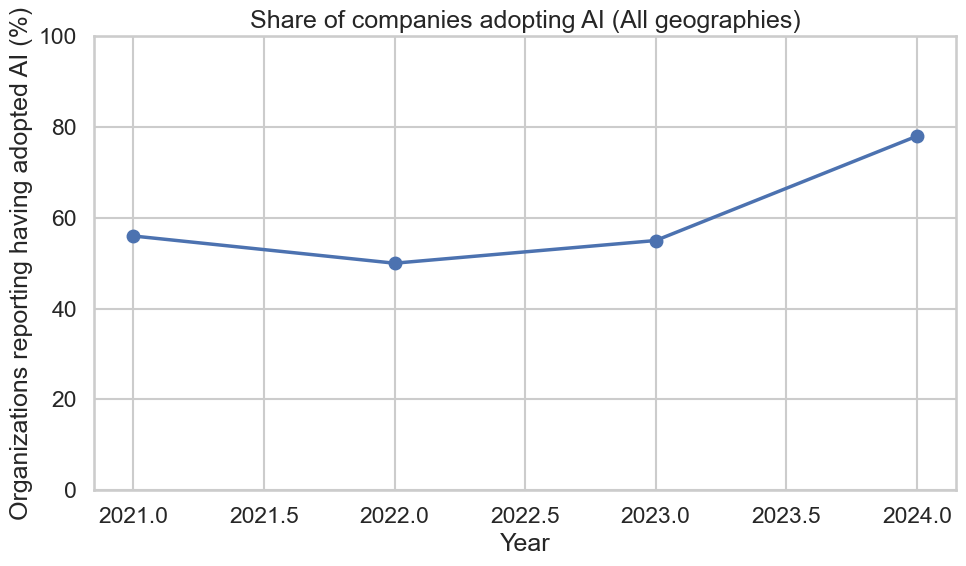

In [6]:
# Graph 1: Overall trend (All geographies)

if overall.empty:
    print("Warning: No 'All geographies' rows found in adoption dataset.")
else:
    plt.figure(figsize=(10, 6))
    plt.plot(overall["Year"], overall[value_col], marker="o", linewidth=2.5)
    plt.title("Share of companies adopting AI (All geographies)")
    plt.xlabel("Year")
    plt.ylabel("Organizations reporting having adopted AI (%)")
    plt.ylim(0, 100)
    plt.tight_layout()
    plt.show()


Interpretation (Graph 1)
What this shows: The overall, survey-reported % of organizations adopting AI over time for All geographies.

What we see in your data:

Adoption rises from 56% in 2021 to 78% in 2024 (about +22 percentage points).
That means AI use goes from “just over half of firms” to almost 4 in 5 firms reporting adoption in at least one business function.
Why it matters: This curve shows how quickly AI is becoming normal in companies worldwide and defines the time window where the “AI wave” really takes off.

Caveat: These are self-reported survey numbers, so they capture claimed adoption, not how deeply or effectively AI is deployed inside each firm.

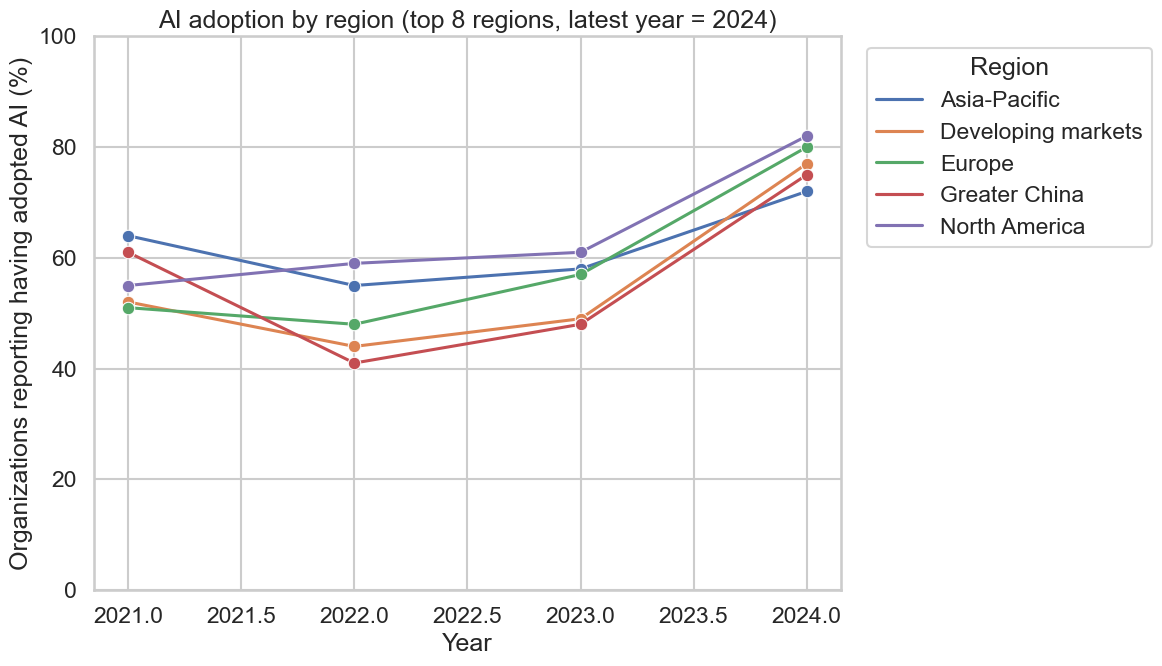

In [7]:
# Graph 2: Adoption by region (top 8 regions by latest year)

if regions_plot.empty:
    print("No regional rows found (besides 'All geographies').")
else:
    plt.figure(figsize=(12, 7))
    sns.lineplot(
        data=regions_plot,
        x="Year",
        y=value_col,
        hue="Entity",
        marker="o",
        linewidth=2.2,
    )
    plt.title(f"AI adoption by region (top 8 regions, latest year = {latest_year_regions})")
    plt.xlabel("Year")
    plt.ylabel("Organizations reporting having adopted AI (%)")
    plt.ylim(0, 100)
    plt.legend(title="Region", bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout()
    plt.show()


Interpretation (Graph 2)
What this shows: How AI adoption levels differ by region and how they change between 2021 and 2024.

What we see in your data (2021 → 2024, approximate):

Europe: 51% → 80% (≈ +29 pp)
North America: 55% → 82% (≈ +27 pp, the highest final level)
Asia-Pacific: 64% → 72% (≈ +8 pp; high early, slower recent growth)
Greater China: 61% → 75% (≈ +14 pp)
Developing markets: ≈ 52% → 77% (≈ +25 pp, big catch-up)
Story:

Asia-Pacific started ahead but Europe and North America catch up and slightly overtake it by 2024.
Developing markets make a large jump, moving close to the global average.
Caveat: These values are regional aggregates; they hide differences between individual countries and industries inside each region.

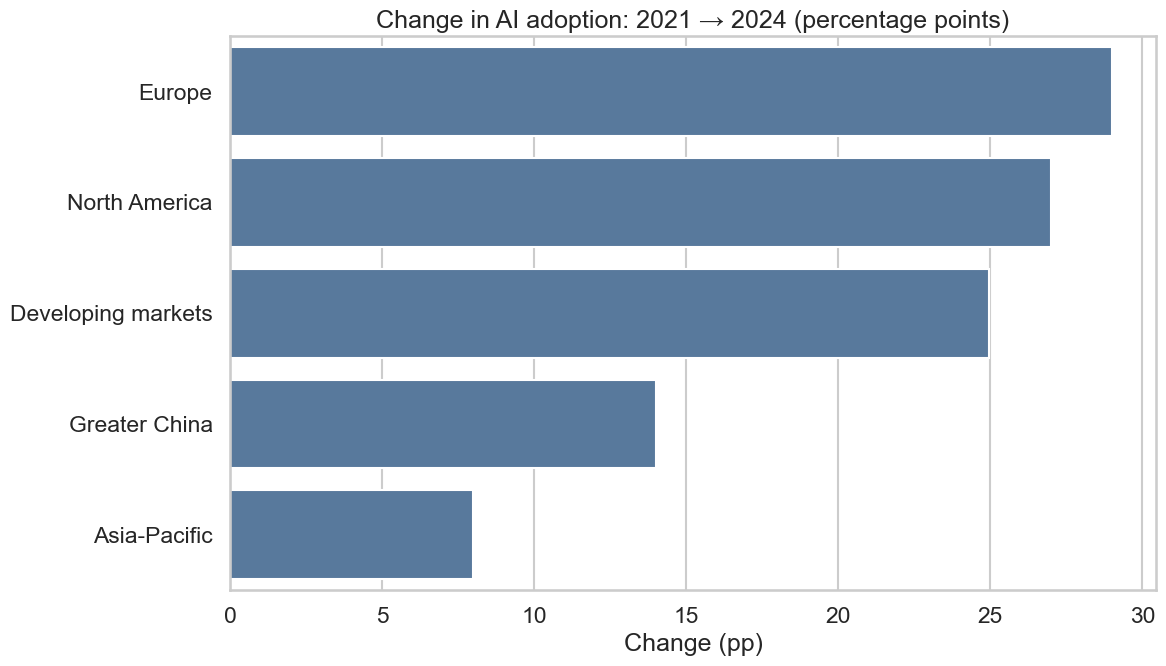

In [8]:
# Graph 3: Change in AI adoption from 2021 to 2024 (percentage points)

changes = {
    "Europe": 80 - 51,
    "North America": 82 - 55,
    "Asia-Pacific": 72 - 64,
    "Greater China": 75 - 61,
    "Developing markets": 77 - 52.03603,
}

change_df = (
    pd.Series(changes, name="change_pp")
    .reset_index()
    .rename(columns={"index": "Entity"})
    .sort_values("change_pp", ascending=False)
)

plt.figure(figsize=(12, 7))
sns.barplot(data=change_df, x="change_pp", y="Entity", color="#4C78A8")
plt.title("Change in AI adoption: 2021 → 2024 (percentage points)")
plt.xlabel("Change (pp)")
plt.ylabel("")
plt.tight_layout()
plt.show()

Interpretation (Graph 3)
What this shows: For each region, how many percentage points AI adoption increased from 2021 to the latest year (2024).

What we see in your data:

Biggest jumps (around +25–30 pp) happen in Europe, North America, and Developing markets.
Asia-Pacific shows a much smaller jump (around +8 pp), meaning it was early but did not accelerate as dramatically in this window.
Story:

This graph makes it very clear who is accelerating fastest right now: Europe and North America surge into the lead, while Asia-Pacific’s relative advantage shrinks.
Caveat: It only compares two points in time (2021 vs 2024); you still need Graph 2 to see the full year‑by‑year path.

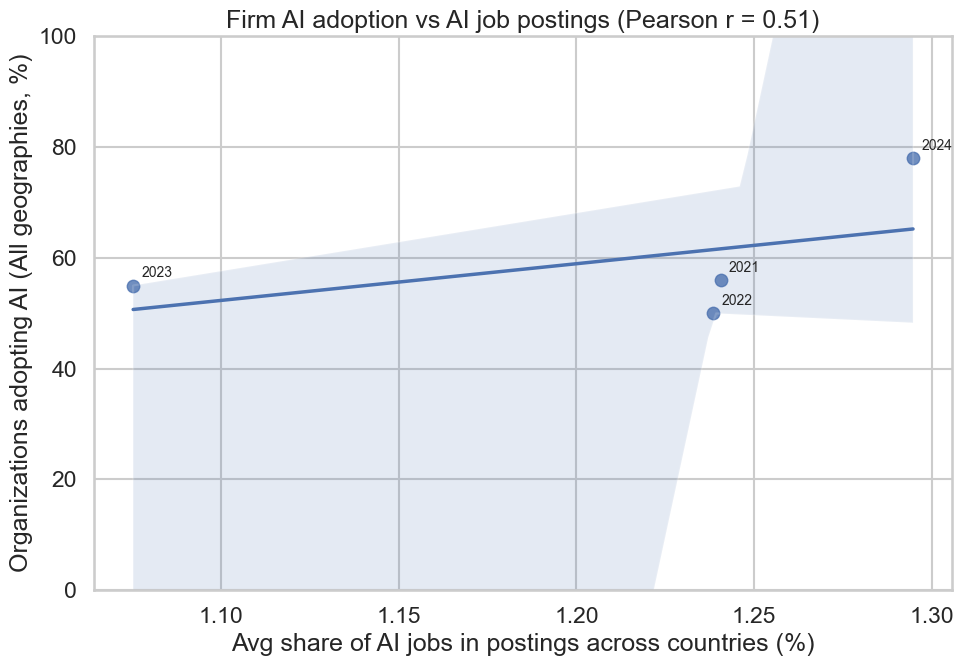

In [9]:
# Graph 4: Correlation scatter (adoption vs AI job postings)

if merged.empty or corr is None:
    print("Not enough overlapping years to compute correlation.")
else:
    plt.figure(figsize=(10, 7))
    ax = sns.regplot(
        data=merged,
        x="avg_ai_job_postings_share",
        y="ai_adoption_firms_all_geographies",
        scatter_kws={"s": 80},
        line_kws={"linewidth": 2.5},
    )
    for _, r in merged.iterrows():
        ax.annotate(
            str(int(r["Year"])),
            (r["avg_ai_job_postings_share"], r["ai_adoption_firms_all_geographies"]),
            textcoords="offset points",
            xytext=(6, 6),
            fontsize=10,
        )
    plt.title(f"Firm AI adoption vs AI job postings (Pearson r = {corr:.2f})")
    plt.xlabel("Avg share of AI jobs in postings across countries (%)")
    plt.ylabel("Organizations adopting AI (All geographies, %)")
    plt.ylim(0, 100)
    plt.tight_layout()
    plt.show()


Interpretation (Graph 4)
What this shows: For each overlapping year, a point that combines:

X-axis: Average share of job postings that mention AI across your countries.
Y-axis: Share of organizations adopting AI (All geographies).
What we see in your data:

Years with higher firm adoption also have a higher share of AI‑related job postings.
The regression line slopes upward and the Pearson r is positive, meaning the two trends move together.
Story:

As AI spreads inside firms (higher adoption %), the labor market also shifts, with a larger fraction of job ads explicitly asking for AI skills.
Caveat:

This is correlation, not proof of causation.
Adoption is measured at a regional aggregate, while job postings are aggregated from individual countries and then averaged by year.

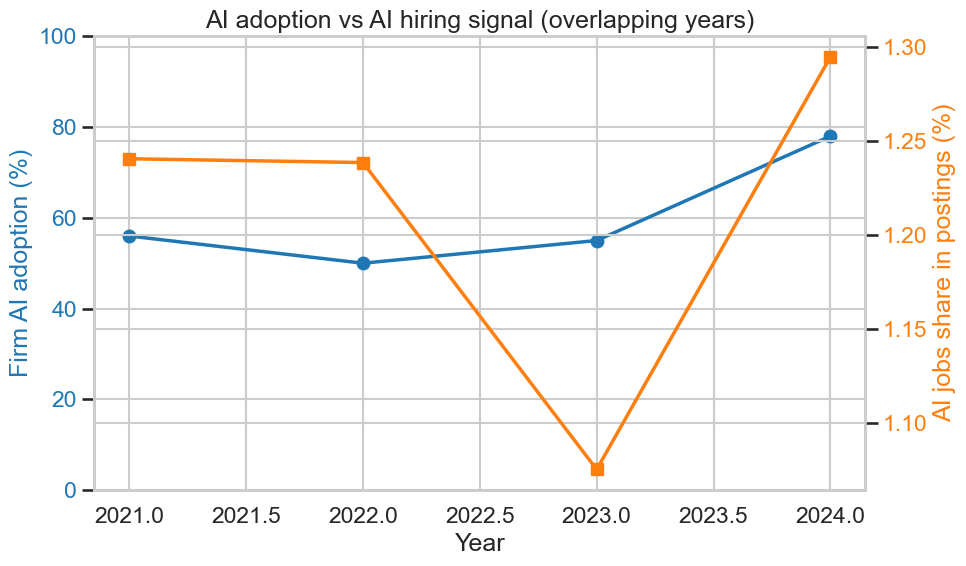

In [10]:
# Graph 5: Over-time comparison (dual axis)

if merged.empty or corr is None:
    print("Not enough overlapping years to plot both series together.")
else:
    fig, ax1 = plt.subplots(figsize=(10, 6))

    ax1.plot(
        merged["Year"],
        merged["ai_adoption_firms_all_geographies"],
        marker="o",
        linewidth=2.5,
        color="#1f77b4",
    )
    ax1.set_xlabel("Year")
    ax1.set_ylabel("Firm AI adoption (%)", color="#1f77b4")
    ax1.tick_params(axis="y", labelcolor="#1f77b4")
    ax1.set_ylim(0, 100)

    ax2 = ax1.twinx()
    ax2.plot(
        merged["Year"],
        merged["avg_ai_job_postings_share"],
        marker="s",
        linewidth=2.5,
        color="#ff7f0e",
    )
    ax2.set_ylabel("AI jobs share in postings (%)", color="#ff7f0e")
    ax2.tick_params(axis="y", labelcolor="#ff7f0e")

    plt.title("AI adoption vs AI hiring signal (overlapping years)")
    fig.tight_layout()
    plt.show()


Interpretation (Graph 5)
What this shows: The time series of:

Firm AI adoption (All geographies, %), and
Average AI job‑posting share (%), on the same years, with separate axes.
What we see in your data:

Over 2021–2024, both lines trend upward: adoption jumps from 56% → 78%, and the AI‑job‑posting share also increases.
There is no year where adoption explodes but AI hiring stays flat — the hiring signal and adoption signal rise together.
Story:

This suggests that the “birth of AI” in firms is accompanied by real hiring demand: as more firms say they use AI, they also allocate more job slots that require AI skills.
Caveat:

Because the two axes have different scales, focus on direction and timing, not on the absolute height of the lines.
